In [7]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [8]:
!find / -name "winequality.csv"

find: ‘/proc/64/task/64/net’: Invalid argument
find: ‘/proc/64/net’: Invalid argument
/winequality.csv


In [9]:
print(os.getcwd())

/content


In [10]:
print(os.listdir)

<built-in function listdir>


In [15]:
import pandas as pd

df = pd.read_csv("/winequality.csv", sep=",")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
df.shape

(1599, 12)

In [18]:
df.info()
df.describe()
df.isnull().sum()
df['quality'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

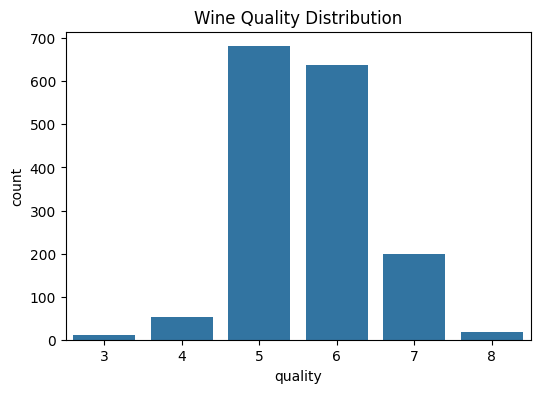

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=df)
plt.title('Wine Quality Distribution')
plt.show()

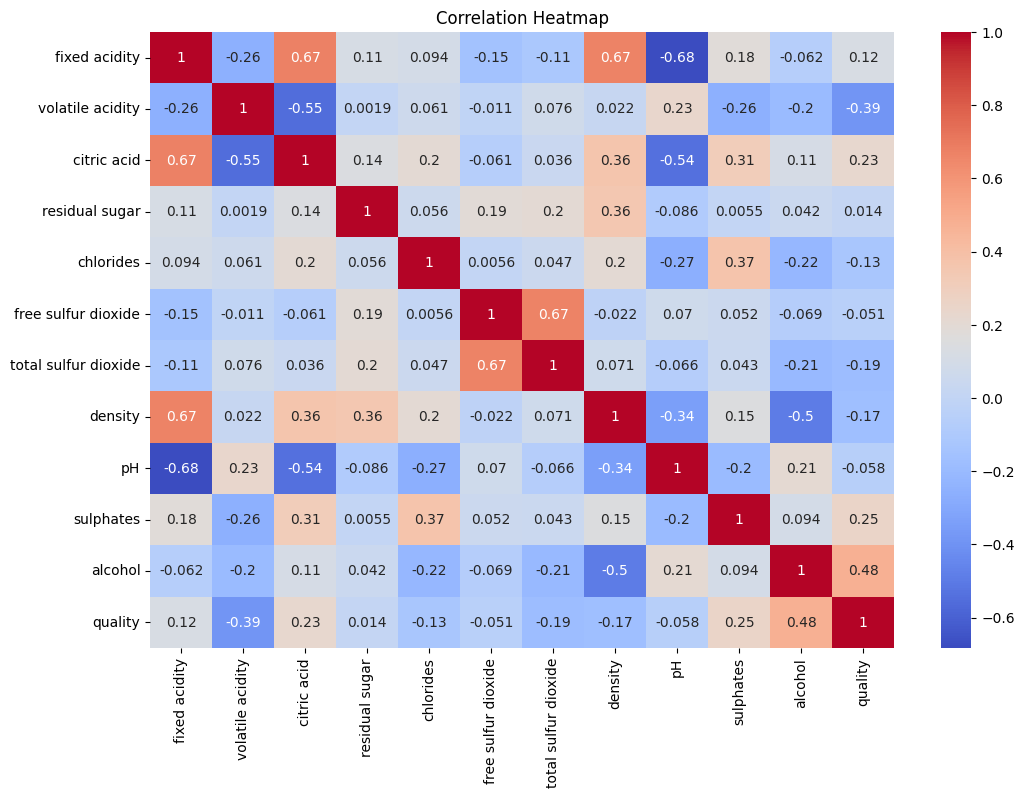

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
df.corr()['quality'].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919


In [25]:
X = df.drop('quality', axis=1)
Y = df['quality']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, Y_train)

predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, predictions)

print("Accuracy:", accuracy)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)
print("Acuracy:",accuracy)

(1279, 11)
(320, 11)
(1279,)
(320,)
Accuracy: 0.659375
(1279, 11)
(320, 11)
(1279,)
(320,)
Acuracy: 0.659375


Feature Importance:
                 Feature  Importance
10               alcohol    0.148987
9              sulphates    0.115690
6   total sulfur dioxide    0.102300
1       volatile acidity    0.096902
7                density    0.094191
4              chlorides    0.080256
8                     pH    0.076720
0          fixed acidity    0.075106
2            citric acid    0.071624
3         residual sugar    0.071444
5    free sulfur dioxide    0.066778


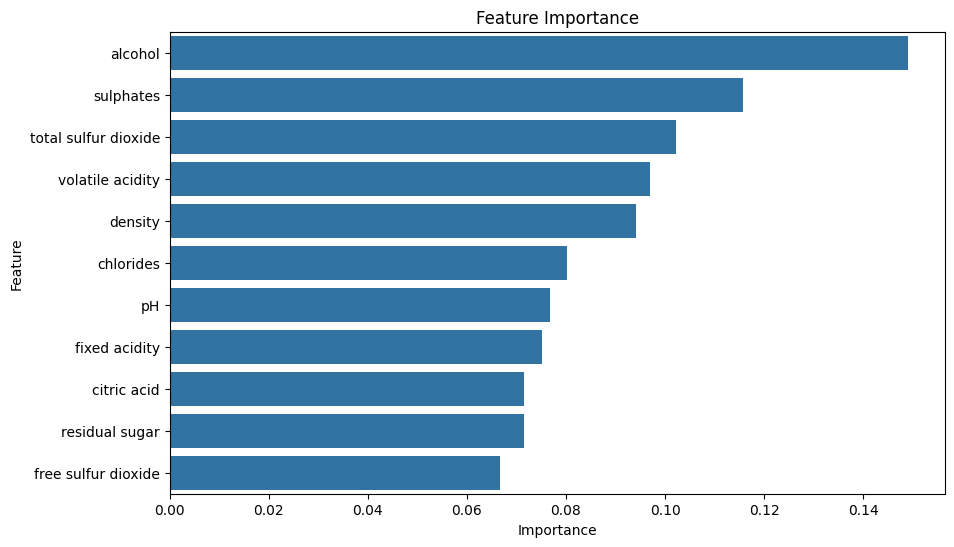


Predicted Wine Quality:
5

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320


Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  7  3  0  0]
 [ 0  0 98 31  1  0]
 [ 0  1 31 91  8  1]
 [ 0  0  0 19 22  1]
 [ 0  0  0  1  4  0]]

===== PROJECT SUMMARY =====
Dataset Shape: (1599, 12)
Training Data Shape: (1279, 11)
Testing Data Shape: (320, 11)
Model Used: Random Forest Classifier
Accuracy: 0.659375


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

In [33]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title("Feature Importance")
plt.show()


# ==========================================
# SAMPLE WINE PREDICTION
# ==========================================

sample_wine = np.array([
    [7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4]
])

prediction = model.predict(sample_wine)

print("\nPredicted Wine Quality:")
print(prediction[0])


# ==========================================
# CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("\nClassification Report:")
print(classification_report(Y_test,predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test,predictions))


# ==========================================
# FINAL PROJECT SUMMARY
# ==========================================

print("\n===== PROJECT SUMMARY =====")
print("Dataset Shape:",df.shape)
print("Training Data Shape:",X_train.shape)
print("Testing Data Shape:",X_test.shape)
print("Model Used: Random Forest Classifier")
print("Accuracy:",accuracy)
print("==========================")

WINE QUALITY PREDICTION PROJECT

Dataset Shape: (1599, 12)
Training Shape: (1279, 11)
Testing Shape: (320, 11)
Model Used: Random Forest Classifier
Accuracy: 65.94 %

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



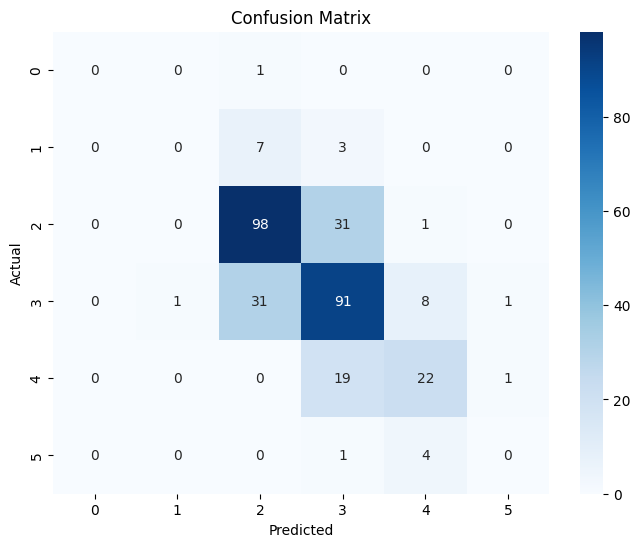


TOP IMPORTANT FEATURES
                 Feature  Importance
10               alcohol    0.148987
9              sulphates    0.115690
6   total sulfur dioxide    0.102300
1       volatile acidity    0.096902
7                density    0.094191
4              chlorides    0.080256
8                     pH    0.076720
0          fixed acidity    0.075106
2            citric acid    0.071624
3         residual sugar    0.071444
5    free sulfur dioxide    0.066778


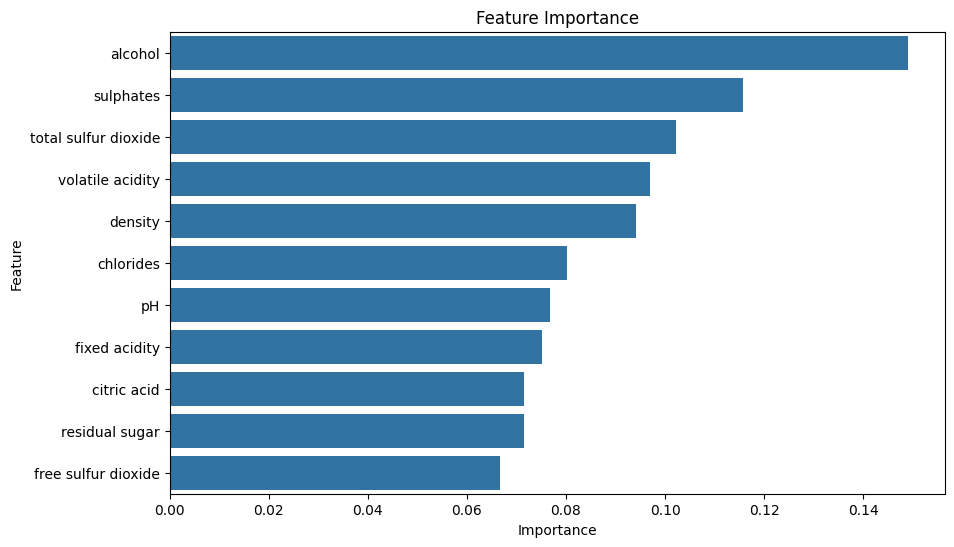


Sample Wine Predicted Quality: 5

PROJECT COMPLETED SUCCESSFULLY


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(Y_test, predictions)

print("="*50)
print("WINE QUALITY PREDICTION PROJECT")
print("="*50)

print("\nDataset Shape:", df.shape)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)
print("Model Used: Random Forest Classifier")
print("Accuracy:", round(accuracy*100,2), "%")

# Classification Report
print("\nCLASSIFICATION REPORT")
print(classification_report(Y_test, predictions, zero_division=0))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(
    confusion_matrix(Y_test, predictions),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTOP IMPORTANT FEATURES")
print(importance_df)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance")
plt.show()

# Sample Prediction
sample_wine = [[7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4]]

predicted_quality = model.predict(sample_wine)

print("\nSample Wine Predicted Quality:", predicted_quality[0])

print("\nPROJECT COMPLETED SUCCESSFULLY")